In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path = "../src/data/san_francisco_listings_details.csv"
df = pd.read_csv(data_path)

# Drop rows without price
df = df.dropna(subset=['price'])

# Focus on short term analysis
df = df[df['minimum_nights'] <= 30]

print("Shape of dataset:", df.shape)

Shape of dataset: (5374, 79)


Select Relevant Features

In [8]:
keep_cols = [
    'description', 'neighbourhood_cleansed', 'latitude', 'longitude', 
    'room_type','accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 
    'price', 'number_of_reviews', 'review_scores_rating', 'host_is_superhost', 
    'availability_30', 'availability_365'
]

df = df[keep_cols]

print("Shape after column selection:", df.shape)
df.head()

Shape after column selection: (5374, 16)


,description,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,number_of_reviews,review_scores_rating,host_is_superhost,availability_30,availability_365
0,Our bright garden unit overlooks a lovely back...,Western Addition,37.77028,-122.43317,Entire home/apt,3,1.0,1.0,2.0,"[""Clothing storage: closet and dresser"", ""Esse...",$157.00,496,4.89,t,5,224
1,We live in a large Victorian house on a quiet ...,Bernal Heights,37.74474,-122.42089,Entire home/apt,4,2.0,2.0,2.0,"[""Carbon monoxide alarm"", ""Shampoo"", ""Hair dry...",$250.00,105,4.87,f,22,357
2,Room is on the second floor so it gets a good ...,Outer Mission,37.73077,-122.44827,Private room,1,2.0,1.0,1.0,"[""Dryer"", ""Essentials"", ""Hangers"", ""Backyard"",...",$67.00,90,4.77,t,0,42
4,"For creative humans who love art, space, photo...",Western Addition,37.77377,-122.43614,Entire home/apt,2,1.5,1.0,1.0,"[""Dedicated workspace"", ""Essentials"", ""Hangers...",$527.00,25,4.86,f,1,327
5,Casa de Paz (House of Peace) is like staying w...,Bayview,37.71750,-122.39698,Private room,2,1.5,1.0,1.0,"[""Blender"", ""Shared BBQ grill: charcoal"", ""Ess...",$108.00,40,4.97,t,30,363


Preprocess the data

In [9]:
# Preprocess the price column
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['price'] = df['price'].round(0).astype(int)
df = df[df['price'] > 0]

# Handle the missing reviews / rooms values
df['no_rating'] = (df['number_of_reviews'] == 0).astype(int)
df['review_scores_rating'].fillna(0, inplace=True)
df = df.dropna(subset=['bathrooms', 'bedrooms', 'beds', 'host_is_superhost'])

# Modify amenity columns
df['amenity_count'] = df['amenities'].apply(lambda x: len(str(x).split(',')))
df.drop(columns=['amenities'], inplace=True)
df['amenity_count'].describe()

# Change neighbourhood column name
df.rename(columns={'neighbourhood_cleansed': 'neighbourhood'}, inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\cuiha\AppData\Local\Temp\ipykernel_55928\2963584223.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\cuiha\AppData\Local\Temp\ipykernel_55928\2963584223.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review_scores_rating'].fillna(0, inplace=True)


In [10]:
# make sure there are no missing values in the selected columns
print(df.isna().sum())

description             52
neighbourhood            0
latitude                 0
longitude                0
room_type                0
accommodates             0
bathrooms                0
bedrooms                 0
beds                     0
price                    0
number_of_reviews        0
review_scores_rating     0
host_is_superhost        0
availability_30          0
availability_365         0
no_rating                0
amenity_count            0
dtype: int64


In [11]:
# Handle Description - potential future use (LLM)

df['description_clean'] = (
    df['description']
    .fillna('')
    .str.replace(r'<br\s*/?>', ' ', regex=True)
    .str.replace(r'[^A-Za-z0-9\s]', '', regex=True)
    .str.lower()
    .str.strip()
)
df['desc_word_count'] = df['description_clean'].apply(lambda x: len(x.split()))
df[['desc_word_count']].describe()

,desc_word_count
count,5209.000000
mean,62.303897
std,23.037112
min,0.000000
25%,48.000000
50%,69.000000
75%,78.000000
max,176.000000


Distribution of Prices

C:\Users\cuiha\AppData\Local\Temp\ipykernel_55928\283618602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


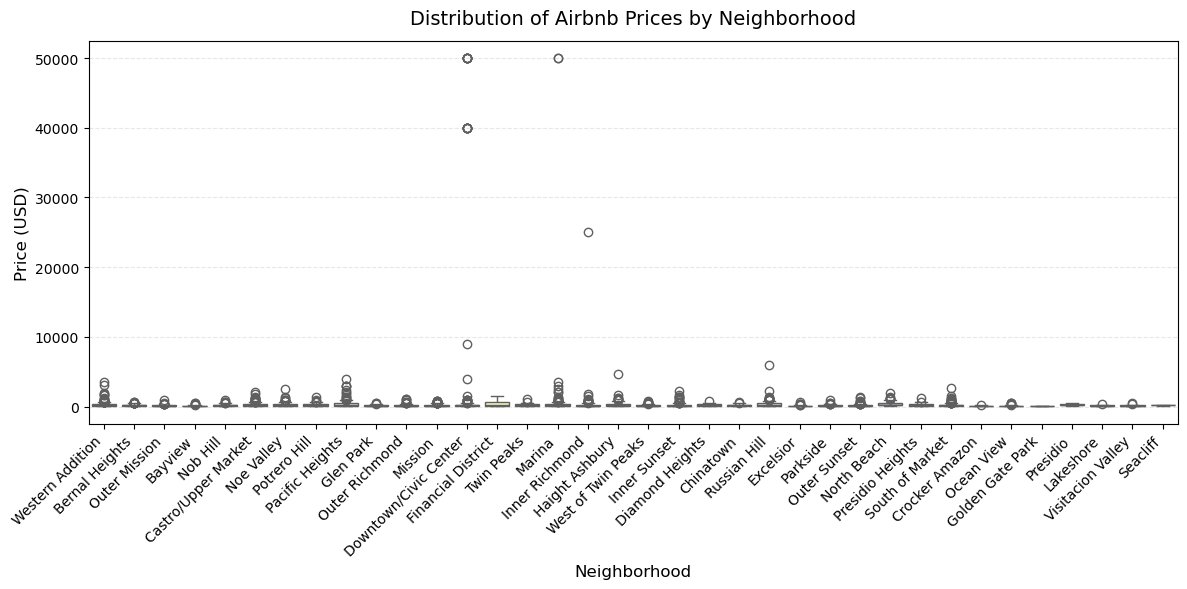

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='neighbourhood',
    y='price',
    data=df,
    palette='Set3'
)

plt.title('Distribution of Airbnb Prices by Neighborhood', fontsize=14, pad=12)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

C:\Users\cuiha\AppData\Local\Temp\ipykernel_55928\3185624365.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='coolwarm')


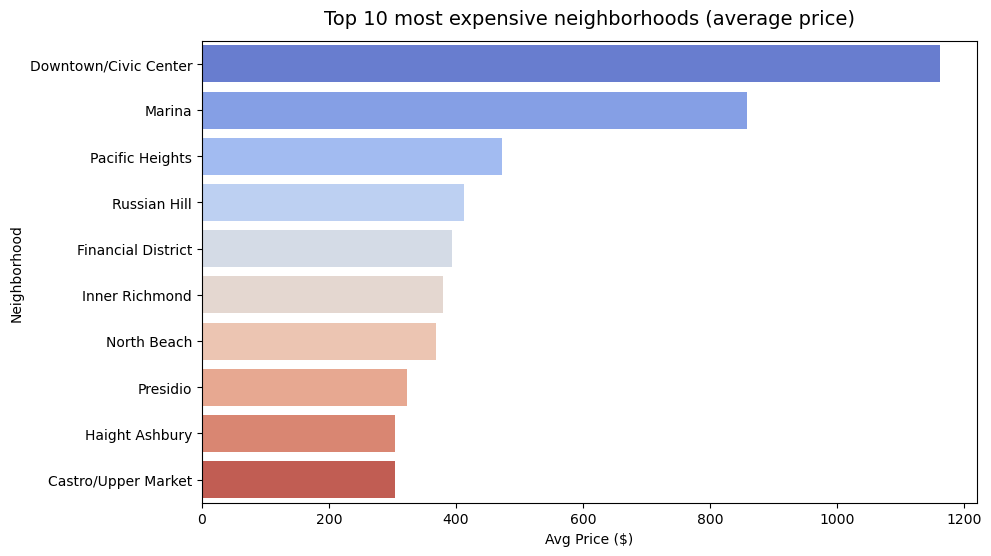

In [13]:
mean_price_per_neigh = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)

# Select top 10 neighborhoods
top10 = mean_price_per_neigh.head(10)

# Display bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index, palette='coolwarm')
plt.title("Top 10 most expensive neighborhoods (average price)", fontsize=14, pad=12)
plt.xlabel("Avg Price ($)")
plt.ylabel("Neighborhood")
plt.show()

In [15]:
import folium
from folium.plugins import MarkerCluster

#Create a base map centered on San Francisco
sf_map = folium.Map(location=[37.77, -122.42], zoom_start=12)

# Visualize all Airbnb listings
marker_cluster = MarkerCluster().add_to(sf_map)
for _, row in df.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Price: ${row['price']:.0f}"
    ).add_to(marker_cluster)

# Average price per neighborhood 
if 'neighbourhood' in df.columns:
    mean_prices = df.groupby('neighbourhood')['price'].mean().reset_index()
    mean_prices = mean_prices.merge(
        df.groupby('neighbourhood')[['latitude', 'longitude']].mean().reset_index(),
        on='neighbourhood'
    )

    for _, row in mean_prices.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=10,
            color=None,
            fill=True,
            fill_color='red' if row['price'] > df['price'].median() else 'green',
            fill_opacity=0.6,
            popup=f"{row['neighbourhood']} — ${row['price']:.0f}"
        ).add_to(sf_map)

# Display map in notebook
sf_map


ModuleNotFoundError: No module named 'folium'

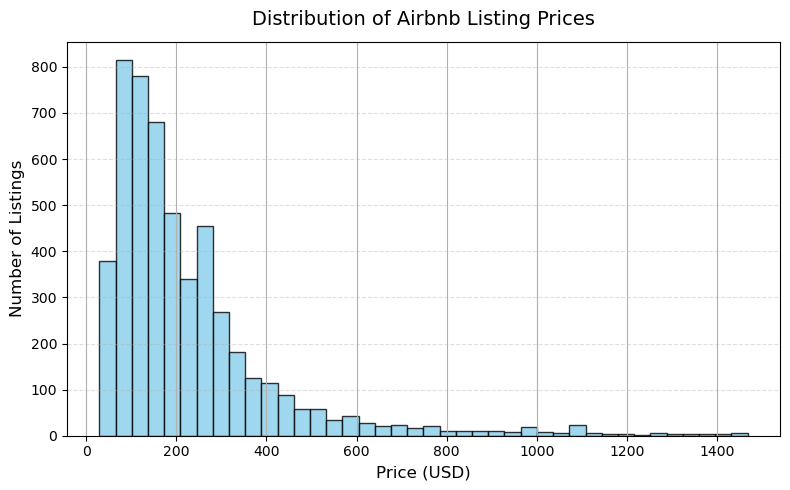

In [16]:
#Because of some outliers, let's also look at the overall price distribution without them.

plt.figure(figsize=(8,5))
# Plot the histogram (cap to 99th percentile to avoid outlier distortion)
df[df['price'] <= np.percentile(df['price'], 99)]['price'].hist(
    bins=40,
    color='skyblue',
    edgecolor='black',
    alpha=0.8
)

# Labels and title
plt.title('Distribution of Airbnb Listing Prices', fontsize=14, pad=12)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [17]:
# Even after removing outliers, the price distribution is still heavily right-skewed. 
# Let's cap extreme values and apply a log transformation.
X = np.percentile(df['price'], 99.5)
df = df[df['price'] <= X]

# Let's apply a log transformation to the price variable to normalize it.
df['log_price'] = np.log(df['price'])
df.drop(columns=['price'], inplace=True)

print("Shape of dataset:", df.shape)

Shape of dataset: (5182, 19)


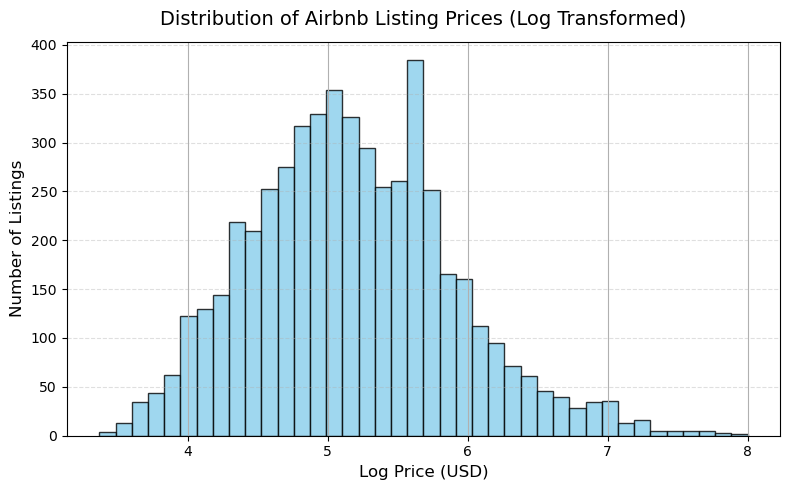

In [18]:
plt.figure(figsize=(8,5))
df['log_price'].hist(
    bins=40,
    color='skyblue',
    edgecolor='black',
    alpha=0.8
)

# Labels and title
plt.title('Distribution of Airbnb Listing Prices (Log Transformed)', fontsize=14, pad=12)
plt.xlabel('Log Price (USD)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Numeric Features Overview

,count,mean,std,min,25%,50%,75%,max
latitude,5182.0,37.768444,0.023817,37.708480,37.752261,37.773833,37.788407,37.809540
longitude,5182.0,-122.431996,0.027704,-122.510362,-122.444874,-122.424011,-122.411791,-122.368710
accommodates,5182.0,3.290042,2.058546,1.000000,2.000000,2.000000,4.000000,16.000000
bathrooms,5182.0,1.293516,0.675139,0.000000,1.000000,1.000000,1.500000,10.000000
bedrooms,5182.0,1.421266,1.018775,0.000000,1.000000,1.000000,2.000000,11.000000
beds,5182.0,1.803358,1.237999,0.000000,1.000000,1.000000,2.000000,16.000000
number_of_reviews,5182.0,68.939792,127.847365,0.000000,2.000000,13.000000,76.000000,1417.000000
review_scores_rating,5182.0,3.968010,1.851359,0.000000,4.500000,4.870000,4.990000,5.000000
availability_30,5182.0,11.111154,10.704340,0.000000,0.000000,8.000000,20.000000,30.000000
availability_365,5182.0,221.061945,112.372117,0.000000,130.000000,243.000000,322.000000,365.000000


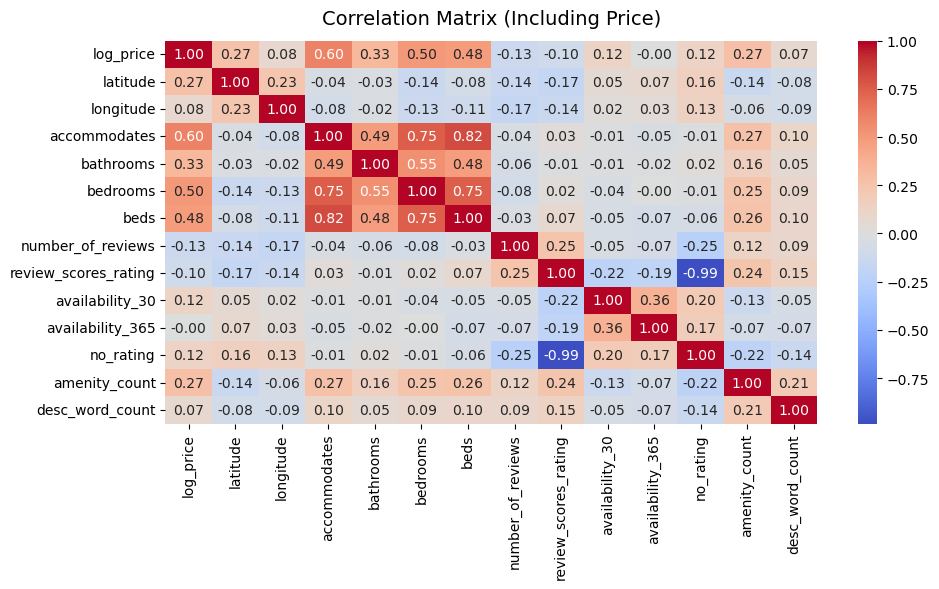

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols = [col for col in numeric_cols if col != 'price']
display(df[numeric_cols].describe().T)

# Correlation heatmap with price
numeric_cols = df.select_dtypes(include=np.number).columns
cols_ordered = ['log_price'] + [col for col in numeric_cols if col != 'log_price']

plt.figure(figsize=(10, 6))
sns.heatmap(df[cols_ordered].corr(), cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Correlation Matrix (Including Price)", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

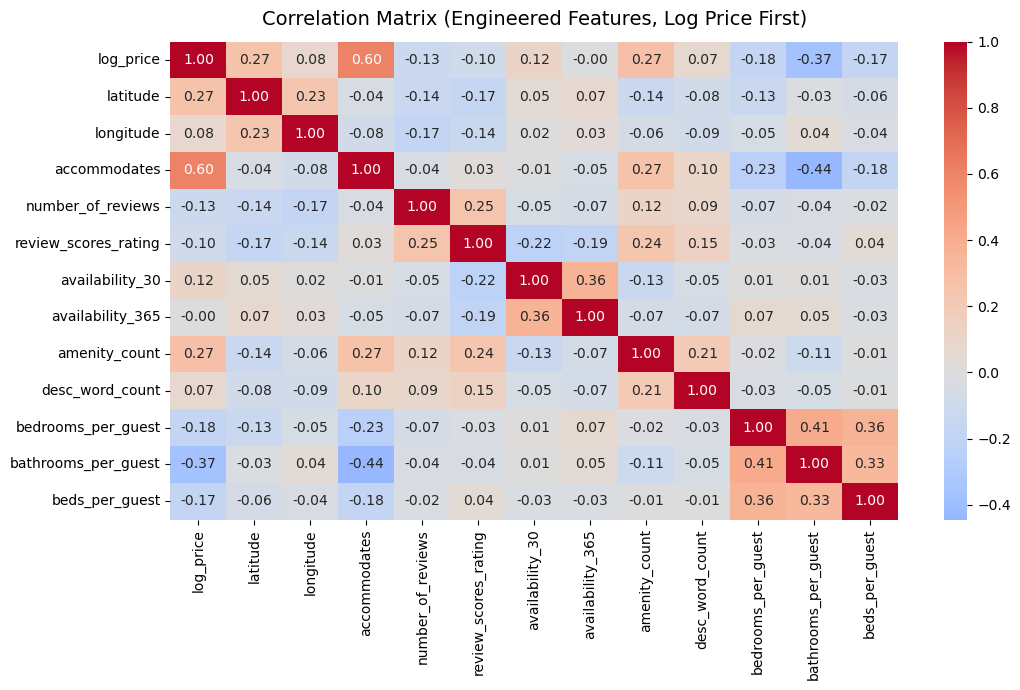

In [20]:
# We need to reduce multicollinearity among 'accommodates', 'bedrooms', 'bathrooms', and 'beds'.
# Create per-guest comfort features; keep 'accommodates' as base


# Avoid division by zero (accommodates should be >=1)
df['accommodates'] = df['accommodates'].clip(lower=1)

df['bedrooms_per_guest']  = df['bedrooms']   / df['accommodates']
df['bathrooms_per_guest'] = df['bathrooms']  / df['accommodates']
df['beds_per_guest']      = df['beds']       / df['accommodates']

# Drop raw counts that are highly collinear (we keep 'accommodates')
df.drop(columns=['bedrooms', 'bathrooms', 'beds'], inplace=True)

# redundant no_rating column
df.drop(columns=['no_rating'], inplace=True)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
cols_ordered = ['log_price'] + [c for c in numeric_cols if c != 'log_price']

corr = df[cols_ordered].corr()

plt.figure(figsize=(11, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Correlation Matrix (Engineered Features, Log Price First)", fontsize=14, pad=12)
plt.tight_layout()
plt.show()


Price vs Room Types

C:\Users\cuiha\AppData\Local\Temp\ipykernel_55928\2753614723.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='log_price', data=df, palette='pastel')


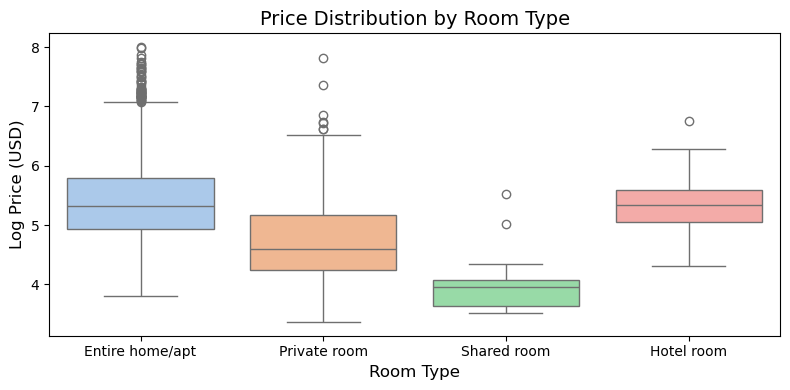

In [21]:
plt.figure(figsize=(8,4))
sns.boxplot(x='room_type', y='log_price', data=df, palette='pastel')
plt.title('Price Distribution by Room Type', fontsize=14)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Log Price (USD)', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
from folium.plugins import HeatMap
import branca.colormap as cm

# Normalize to [0, 1] for the HeatMap weights
lp_min = df['log_price'].min()
lp_max = df['log_price'].max()
df['log_price_norm'] = (df['log_price'] - lp_min) / (lp_max - lp_min + 1e-12)

# --- Create a base map centered on San Francisco ---
sf_map = folium.Map(location=[37.77, -122.42], zoom_start=12, tiles='CartoDB positron')

# --- Prepare heat data: [lat, lon, weight] where weight = normalized log_price ---
heat_data = df[['latitude', 'longitude', 'log_price_norm']].values.tolist()

# --- Add HeatMap layer ---
HeatMap(
    heat_data,
    radius=10,     # spread of each point
    blur=15,       # smoothing
    max_zoom=13,   # how the heat behaves when zooming
    gradient={0.0:'blue', 0.25:'cyan', 0.5:'lime', 0.75:'orange', 1.0:'red'}    # because we normalized weights to [0, 1]
).add_to(sf_map)


# --- (Optional) Add a legend for the log-price scale ---
colormap = cm.linear.YlOrRd_09.scale(lp_min, lp_max)
colormap.caption = "Log(Price) intensity"
colormap.add_to(sf_map)

# Display the map in the notebook
sf_map


ModuleNotFoundError: No module named 'folium'

Train / Test Split for Stage 1 (s1) (Basic Models without description (LLM))

In [ ]:
from sklearn.model_selection import train_test_split
y_s1 = df['log_price']
X_s1 = df.drop(columns=['log_price', 'description', 'description_clean'])
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_s1, y_s1, test_size=0.2, random_state=229
)

print("Train set shape:", X_train_s1.shape)
print("Test set shape:", X_test_s1.shape)

Train set shape: (4145, 15)
Test set shape: (1037, 15)


In [27]:
train_s1_df = X_train_s1.copy()
train_s1_df['log_price'] = y_train_s1

test_s1_df = X_test_s1.copy()
test_s1_df['log_price'] = y_test_s1

# Save to disk
train_s1_df.to_csv("../src/data/train_s1.csv", index=False)
test_s1_df.to_csv("../src/data/test_s1.csv", index=False)